# Fase 1 y Fase 2 — Events + Relaciones entre tablas / Reviews
## Análisis exploratorio estructurado
**Rocío** — Target: purchase

In [56]:
import sys, os, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
from pathlib import Path
ROOT = Path("../../").resolve(); sys.path.insert(0, str(ROOT / "src"))
from utils import cargarDatos
pd.set_option("display.max_columns", None); sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

events = cargarDatos("events"); customers = cargarDatos("customers")
orders = cargarDatos("orders"); order_items = cargarDatos("order_items")
products = cargarDatos("products"); reviews = cargarDatos("reviews"); sessions = cargarDatos("sessions")

events["timestamp"] = pd.to_datetime(events["timestamp"])
orders["order_time"] = pd.to_datetime(orders["order_time"])
reviews["review_time"] = pd.to_datetime(reviews["review_time"])
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
sessions["start_time"] = pd.to_datetime(sessions["start_time"])

COLORS_BAR = ["#e34948","#eda100","#c9c22f","#7fbf5f","#1baf7a"]


Archivo cargado correctamente: events.csv
Dimensiones: 760958 filas x 10 columnas

Archivo cargado correctamente: customers.csv
Dimensiones: 20000 filas x 7 columnas

Archivo cargado correctamente: orders.csv
Dimensiones: 33580 filas x 10 columnas

Archivo cargado correctamente: order_items.csv
Dimensiones: 59163 filas x 5 columnas

Archivo cargado correctamente: products.csv
Dimensiones: 1197 filas x 6 columnas

Archivo cargado correctamente: reviews.csv
Dimensiones: 10780 filas x 6 columnas

Archivo cargado correctamente: sessions.csv
Dimensiones: 120000 filas x 6 columnas


## 1. Análisis Univariable

### 1.0 Calidad de datos

Verificación de integridad referencial, consistencia events-orders y duplicados.

In [57]:
# ── Integridad referencial ──
print("=== INTEGRIDAD REFERENCIAL ===")
print(f"Orders con customer_id invalido: {(~orders.customer_id.isin(customers.customer_id)).sum()}")
print(f"Order_items con order_id invalido: {(~order_items.order_id.isin(orders.order_id)).sum()}")
print(f"Order_items con product_id invalido: {(~order_items.product_id.isin(products.product_id)).sum()}")
print(f"Reviews con order_id invalido: {(~reviews.order_id.isin(orders.order_id)).sum()}")
print(f"Reviews con product_id invalido: {(~reviews.product_id.isin(products.product_id)).sum()}")
print(f"Sessions con customer_id invalido: {(~sessions.customer_id.isin(customers.customer_id)).sum()}")
print("Resultado: 0 filas huerfanas en todas las tablas")

# ── Sync events-orders ──
print(f"\n=== SYNC EVENTS-ORDERS ===")
n_purchases_events = (events.event_type == "purchase").sum()
n_orders = len(orders)
print(f"Purchase events: {n_purchases_events}")
print(f"Orders: {n_orders}")
print(f"Coinciden: {n_purchases_events == n_orders}")

# ── Duplicados ──
print(f"\n=== DUPLICADOS ===")
print(f"Events duplicados exactos: {events.duplicated().sum()}")
print(f"Reviews duplicadas (mismo order+product+rating): {reviews.duplicated(subset=['order_id','product_id','rating']).sum()}")
print(f"Reviews contradictorias (mismo order+product, rating distinto): {reviews.duplicated(subset=['order_id','product_id'], keep=False).sum() - reviews.duplicated(subset=['order_id','product_id','rating']).sum()}")

=== INTEGRIDAD REFERENCIAL ===
Orders con customer_id invalido: 0
Order_items con order_id invalido: 0
Order_items con product_id invalido: 0
Reviews con order_id invalido: 0
Reviews con product_id invalido: 0
Sessions con customer_id invalido: 0
Resultado: 0 filas huerfanas en todas las tablas

=== SYNC EVENTS-ORDERS ===
Purchase events: 33580
Orders: 33580
Coinciden: True

=== DUPLICADOS ===
Events duplicados exactos: 0
Reviews duplicadas (mismo order+product+rating): 4
Reviews contradictorias (mismo order+product, rating distinto): 26


### 1.1 Events — variables numéricas por tipo de evento

=== DESCRIPTIVA ===
       amount_usd (purchase)  discount_pct (purchase)  qty (add_to_cart)  \
count               33580.00                 33580.00          143126.00   
mean                  133.81                     7.16               1.30   
std                   152.13                     7.47               0.78   
min                     2.80                     0.00               1.00   
25%                    40.30                     0.00               1.00   
50%                    86.46                     5.00               1.00   
75%                   174.27                    15.00               1.00   
max                  2984.58                    20.00               4.00   

       cart_size (checkout)  
count              44909.00  
mean                   2.29  
std                    1.61  
min                    1.00  
25%                    1.00  
50%                    2.00  
75%                    3.00  
max                   13.00  


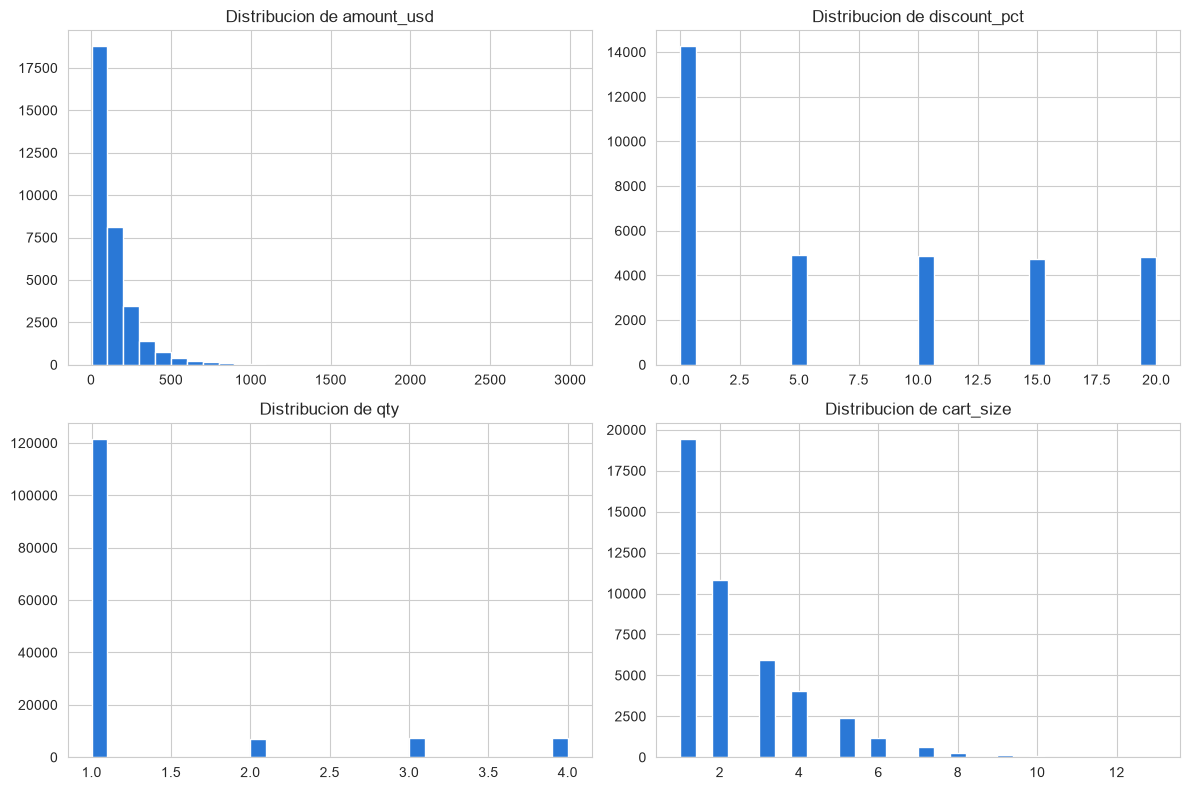

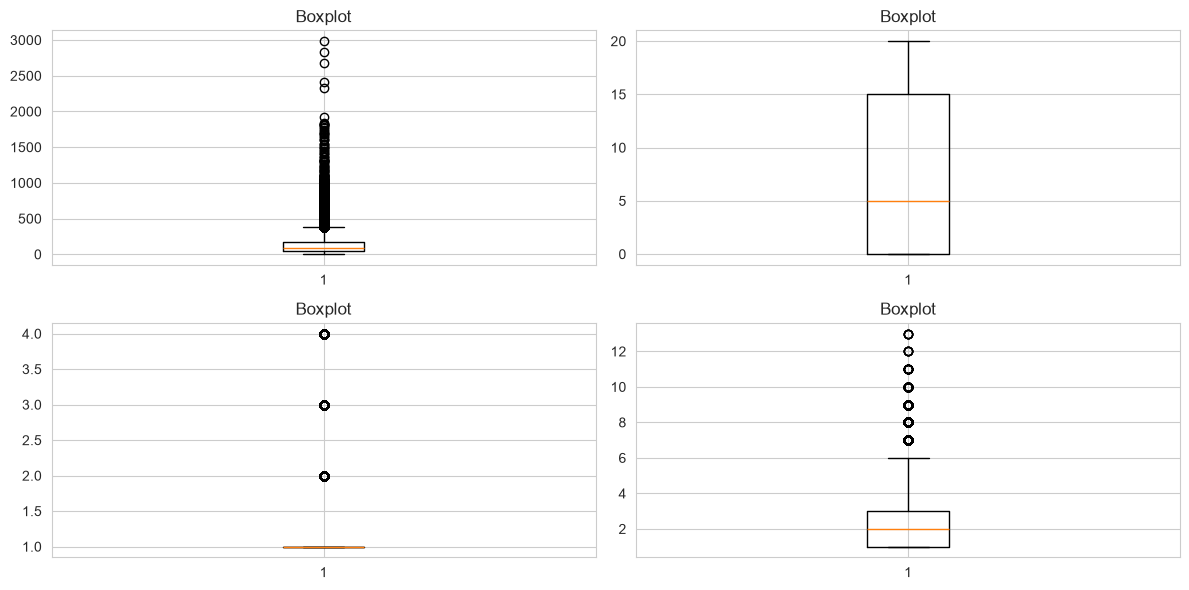

amount_usd: media $134, mediana $86
qty: pico en 1, max 4
cart_size: media 2.3 items


In [58]:
# Cada columna numérica está poblada en un tipo de evento distinto
add_to_cart = events[events["event_type"] == "add_to_cart"]
checkout = events[events["event_type"] == "checkout"]
purchases = events[events["event_type"] == "purchase"]

amount = purchases["amount_usd"]; discount = purchases["discount_pct"]
qty = add_to_cart["qty"]; cart_size = checkout["cart_size"]

print("=== DESCRIPTIVA ===")
print(pd.DataFrame({
    "amount_usd (purchase)": amount.describe(),
    "discount_pct (purchase)": discount.describe(),
    "qty (add_to_cart)": qty.describe(),
    "cart_size (checkout)": cart_size.describe()
}).round(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, v, t in zip(axes.flat, [amount, discount, qty, cart_size],
    ["amount_usd","discount_pct","qty","cart_size"]):
    v.hist(ax=ax, bins=30, color="#2a78d6", edgecolor="white")
    ax.set_title(f"Distribucion de {t}")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, v in zip(axes.flat, [amount, discount, qty, cart_size]):
    ax.boxplot(v.dropna()); ax.set_title(f"Boxplot")
plt.tight_layout(); plt.show()

print(f"amount_usd: media ${amount.mean():.0f}, mediana ${amount.median():.0f}")
print(f"qty: pico en 1, max {int(qty.max())}")
print(f"cart_size: media {cart_size.mean():.1f} items")

### 1.2 Events — variables categóricas

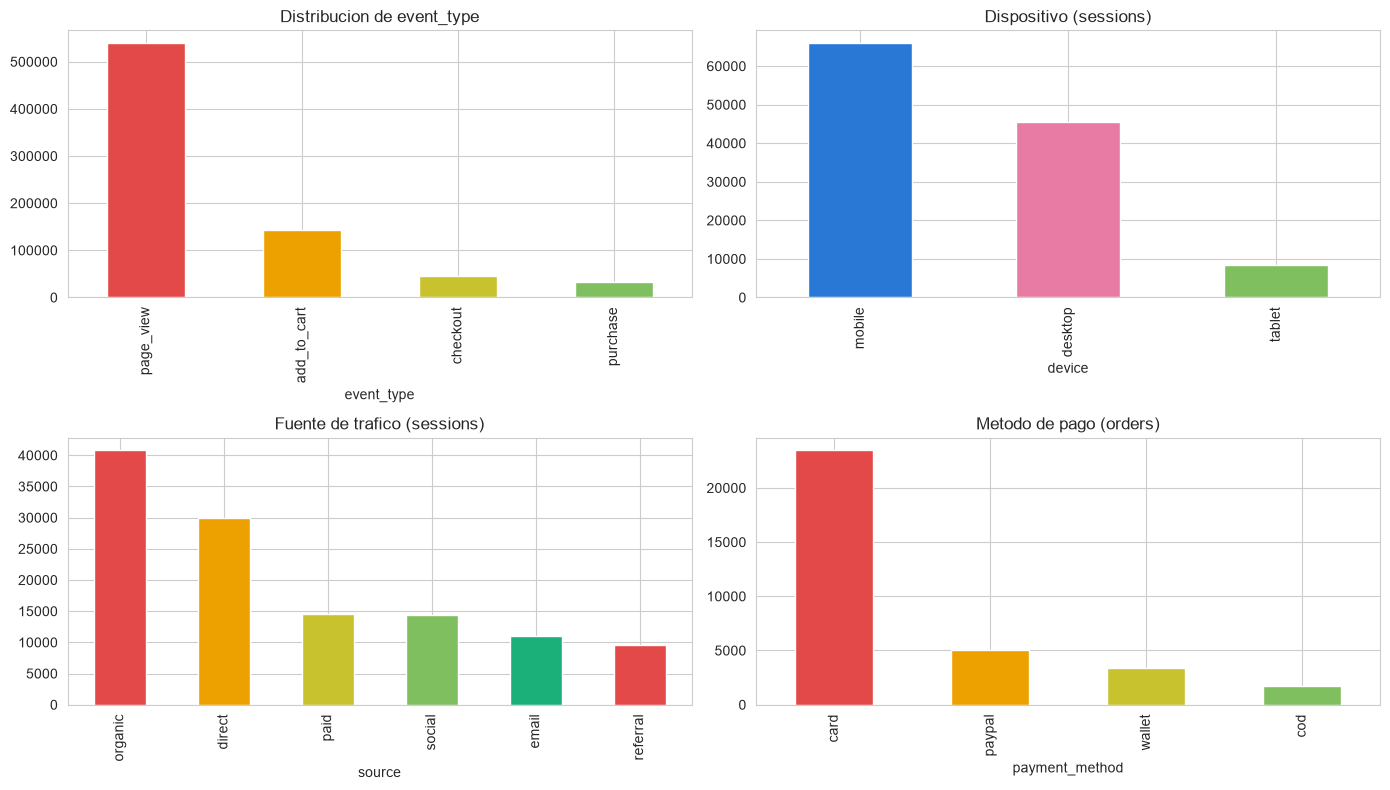

event_type:
event_type
page_view      539343
add_to_cart    143126
checkout        44909
purchase        33580
Name: count, dtype: int64

device:
device
mobile     65942
desktop    45547
tablet      8511
Name: count, dtype: int64

source:
source
organic     40776
direct      29861
paid        14465
social      14389
email       10949
referral     9560
Name: count, dtype: int64

payment:
payment_method
card      23455
paypal     5032
wallet     3373
cod        1720
Name: count, dtype: int64


In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
events["event_type"].value_counts().plot(kind="bar", ax=axes[0,0], color=COLORS_BAR)
axes[0,0].set_title("Distribucion de event_type")
sessions["device"].value_counts().plot(kind="bar", ax=axes[0,1], color=["#2a78d6","#e87ba4","#7fbf5f"])
axes[0,1].set_title("Dispositivo (sessions)")
sessions["source"].value_counts().plot(kind="bar", ax=axes[1,0], color=COLORS_BAR)
axes[1,0].set_title("Fuente de trafico (sessions)")
orders["payment_method"].value_counts().plot(kind="bar", ax=axes[1,1], color=COLORS_BAR)
axes[1,1].set_title("Metodo de pago (orders)")
plt.tight_layout(); plt.show()
print(f"event_type:\n{events.event_type.value_counts()}\n")
print(f"device:\n{sessions.device.value_counts()}\n")
print(f"source:\n{sessions.source.value_counts()}\n")
print(f"payment:\n{orders.payment_method.value_counts()}")

### 1.3 Events — evolución temporal

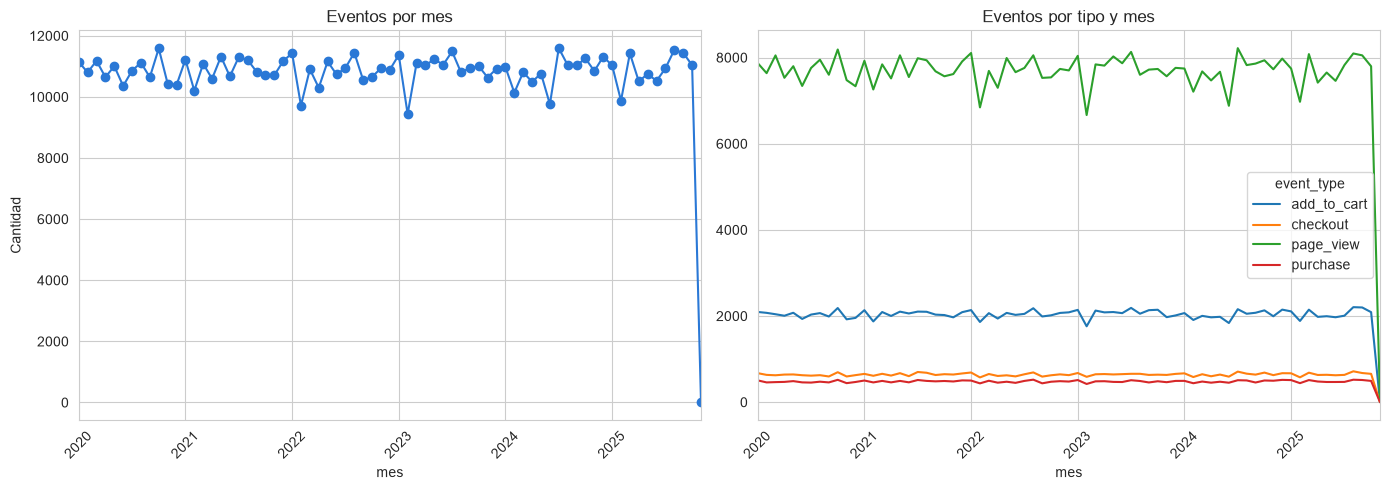

Total: 760,958 eventos | Promedio: 10718/mes
Trafico estable ~10k eventos/mes (sintetico)


In [60]:
events["mes"] = events["timestamp"].dt.to_period("M")
evol = events.groupby("mes").size()
funnel = events.groupby(["mes","event_type"]).size().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
evol.plot(ax=ax1, marker="o", color="#2a78d6", linewidth=1.5)
ax1.set_title("Eventos por mes"); ax1.set_ylabel("Cantidad"); ax1.tick_params(axis="x", rotation=45)
funnel.plot(ax=ax2, linewidth=1.5)
ax2.set_title("Eventos por tipo y mes"); ax2.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
print(f"Total: {len(events):,} eventos | Promedio: {evol.mean():.0f}/mes")
print("Trafico estable ~10k eventos/mes (sintetico)")

### 1.4 Reviews — distribución

=== RATINGS ===
rating
1     423
2     757
3    1980
4    3565
5    4055
Name: count, dtype: int64
Rating promedio: 3.93/5


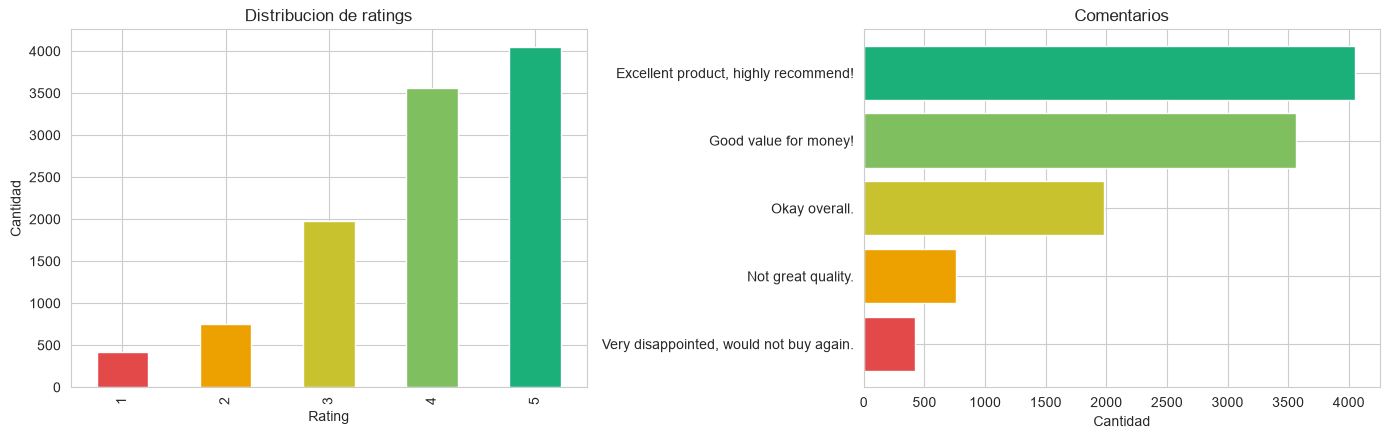

review_text: 5 frases fijas 1:1 con rating, sin NLP posible


In [61]:
print("=== RATINGS ==="); print(reviews.rating.value_counts().sort_index())
print(f"Rating promedio: {reviews.rating.mean():.2f}/5")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
reviews.rating.value_counts().sort_index().plot(kind="bar", ax=ax1, color=COLORS_BAR)
ax1.set_title("Distribucion de ratings"); ax1.set_xlabel("Rating"); ax1.set_ylabel("Cantidad")

orden = ["Very disappointed, would not buy again.","Not great quality.","Okay overall.","Good value for money!","Excellent product, highly recommend!"]
conteo = reviews.review_text.value_counts().reindex(orden)
ax2.barh(orden, conteo.values, color=COLORS_BAR)
ax2.set_title("Comentarios"); ax2.set_xlabel("Cantidad")
plt.tight_layout(); plt.show()
print("review_text: 5 frases fijas 1:1 con rating, sin NLP posible")

## 2. Análisis Bivariable — target = purchase

### 2.1 Conversión por dispositivo, fuente y país

Conversion global: 28.0%


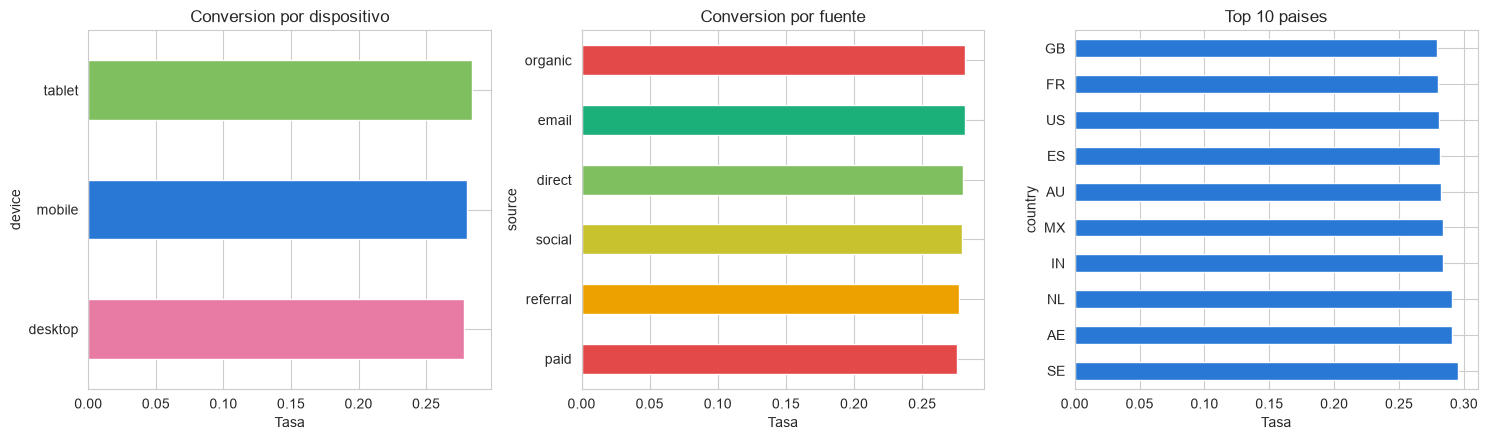

In [62]:
ses_events = events.groupby("session_id")["event_type"].apply(set)
ses = pd.DataFrame({"session_id": ses_events.index})
ses["purchase"] = ses_events.apply(lambda x: "purchase" in x).astype(int)
ses = ses.merge(sessions, on="session_id", how="left")

print(f"Conversion global: {ses.purchase.mean()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ses.groupby("device")["purchase"].mean().sort_values().plot(kind="barh", ax=axes[0], color=["#e87ba4","#2a78d6","#7fbf5f"])
axes[0].set_title("Conversion por dispositivo"); axes[0].set_xlabel("Tasa")
ses.groupby("source")["purchase"].mean().sort_values().plot(kind="barh", ax=axes[1], color=COLORS_BAR)
axes[1].set_title("Conversion por fuente"); axes[1].set_xlabel("Tasa")
ses.groupby("country")["purchase"].mean().sort_values(ascending=False).head(10).plot(kind="barh", ax=axes[2], color="#2a78d6")
axes[2].set_title("Top 10 paises"); axes[2].set_xlabel("Tasa")
plt.tight_layout(); plt.show()

**Interpretación:** Tasas ~28% sin importar dispositivo, fuente ni país. Datos sintéticos.

### 2.2 Precio y descuento — según compra

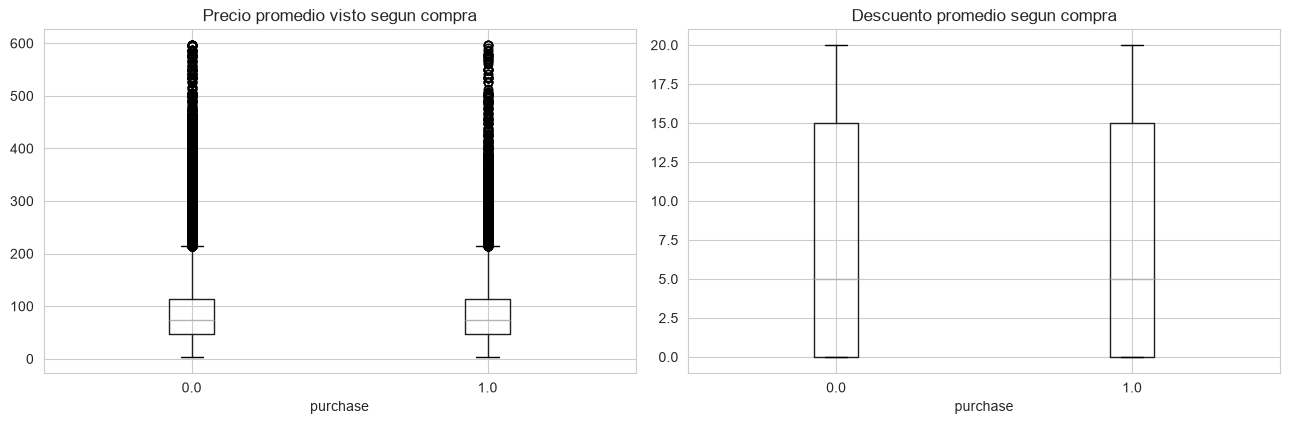

In [63]:
# Precio promedio de productos vistos por sesion
ev_prod = events[events["event_type"] == "page_view"].merge(products[["product_id","price_usd"]], on="product_id", how="left")
avg_price = ev_prod.groupby("session_id")["price_usd"].mean()
ses["avg_price"] = ses["session_id"].map(avg_price)

# Descuento promedio por sesion (purchase events tienen discount_pct)
disc_ses = events[events["event_type"]=="purchase"].groupby("session_id")["discount_pct"].mean()
ses["avg_disc"] = ses["session_id"].map(disc_ses)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ses.boxplot(column="avg_price", by="purchase", ax=axes[0])
axes[0].set_title("Precio promedio visto segun compra")
ses.boxplot(column="avg_disc", by="purchase", ax=axes[1])
axes[1].set_title("Descuento promedio segun compra")
plt.suptitle(""); plt.tight_layout(); plt.show()

### 2.3 Relación precio — rating

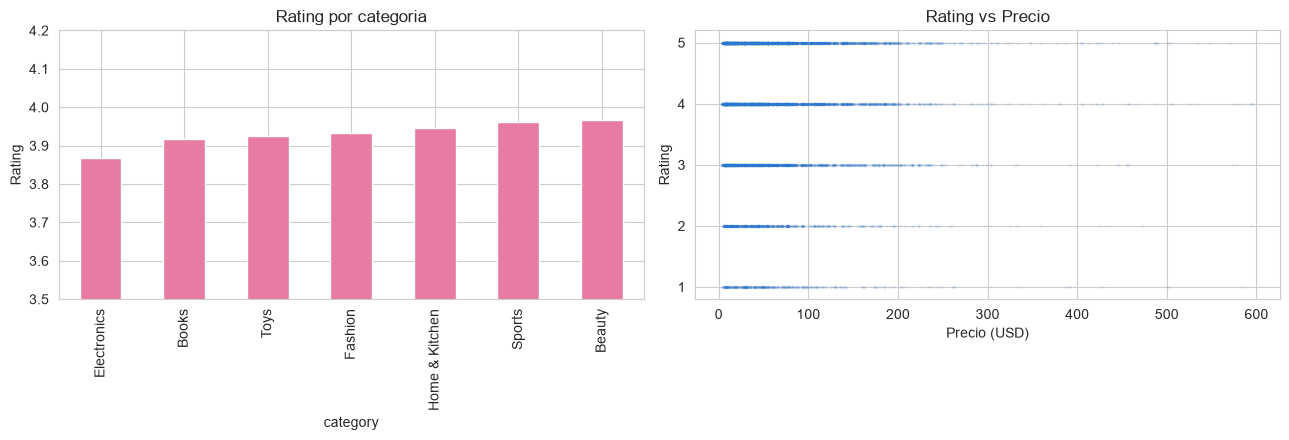

Correlacion precio-rating: 0.001


In [64]:
rp = reviews.merge(products[["product_id","category","price_usd"]], on="product_id")
rcat = rp.groupby("category")["rating"].mean().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
rcat.plot(kind="bar", ax=ax1, color="#e87ba4")
ax1.set_title("Rating por categoria"); ax1.set_ylabel("Rating"); ax1.set_ylim(3.5, 4.2)
ax2.scatter(rp["price_usd"], rp["rating"], alpha=0.05, s=2, color="#2a78d6")
ax2.set_title("Rating vs Precio"); ax2.set_xlabel("Precio (USD)"); ax2.set_ylabel("Rating"); ax2.set_yticks([1,2,3,4,5])
plt.tight_layout(); plt.show()
print(f"Correlacion precio-rating: {rp.price_usd.corr(rp.rating):.3f}")

## 3. Análisis Multivariable

### 3.1 Coherencia temporal entre tablas

In [65]:
rev_ord = reviews.merge(orders[["order_id","order_time"]], on="order_id")
anomalias_rev = (rev_ord.review_time < rev_ord.order_time).mean()*100
ord_sig = orders.merge(customers[["customer_id","signup_date"]], on="customer_id")
anomalias_ord = (ord_sig.order_time < ord_sig.signup_date).mean()*100
print(f"Reviews anteriores a su orden: {anomalias_rev:.1f}%")
print(f"Ordenes anteriores al signup: {anomalias_ord:.1f}%")
print("Dataset sintetico: ~50% violan el orden causal")

Reviews anteriores a su orden: 50.9%
Ordenes anteriores al signup: 50.4%
Dataset sintetico: ~50% violan el orden causal


### 3.2 Embudo de conversión + desbalance

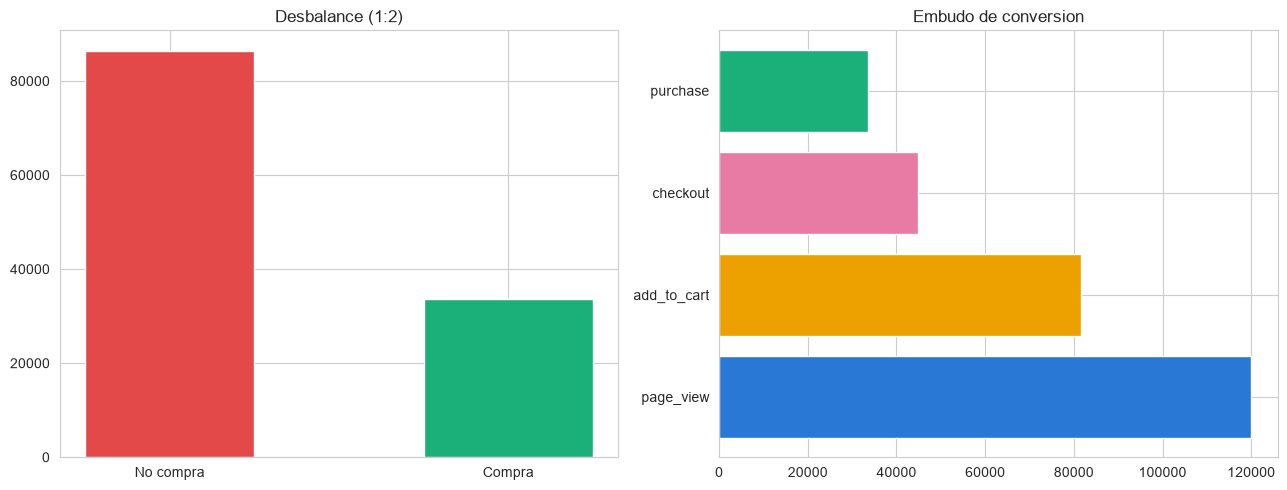

Compra: 33580 (28.0%) | No: 86420 (72.0%)
view->cart: 67.9% | cart->checkout: 55.1% | checkout->compra: 74.8%


In [66]:
ses_events = events.groupby("session_id")["event_type"].apply(set)
hv = ses_events.apply(lambda x: "page_view" in x)
hc = ses_events.apply(lambda x: "add_to_cart" in x)
hk = ses_events.apply(lambda x: "checkout" in x)
hp = ses_events.apply(lambda x: "purchase" in x)

t = len(ses_events); nb = hp.sum(); nn = t-nb

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.bar(["No compra","Compra"], [nn,nb], color=["#e34948","#1baf7a"], width=0.5)
ax1.set_title(f"Desbalance (1:{nn//nb})")
ax2.barh(["page_view","add_to_cart","checkout","purchase"],
    [hv.sum(), hc.sum(), hk.sum(), hp.sum()],
    color=["#2a78d6","#eda100","#e87ba4","#1baf7a"])
ax2.set_title("Embudo de conversion")
plt.tight_layout(); plt.show()
print(f"Compra: {nb} ({nb/t*100:.1f}%) | No: {nn} ({nn/t*100:.1f}%)")
print(f"view->cart: {hc.sum()/hv.sum()*100:.1f}% | cart->checkout: {hk.sum()/hc.sum()*100:.1f}% | checkout->compra: {hp.sum()/hk.sum()*100:.1f}%")

### 3.3 Matriz de correlación — todas las tablas (nivel producto)

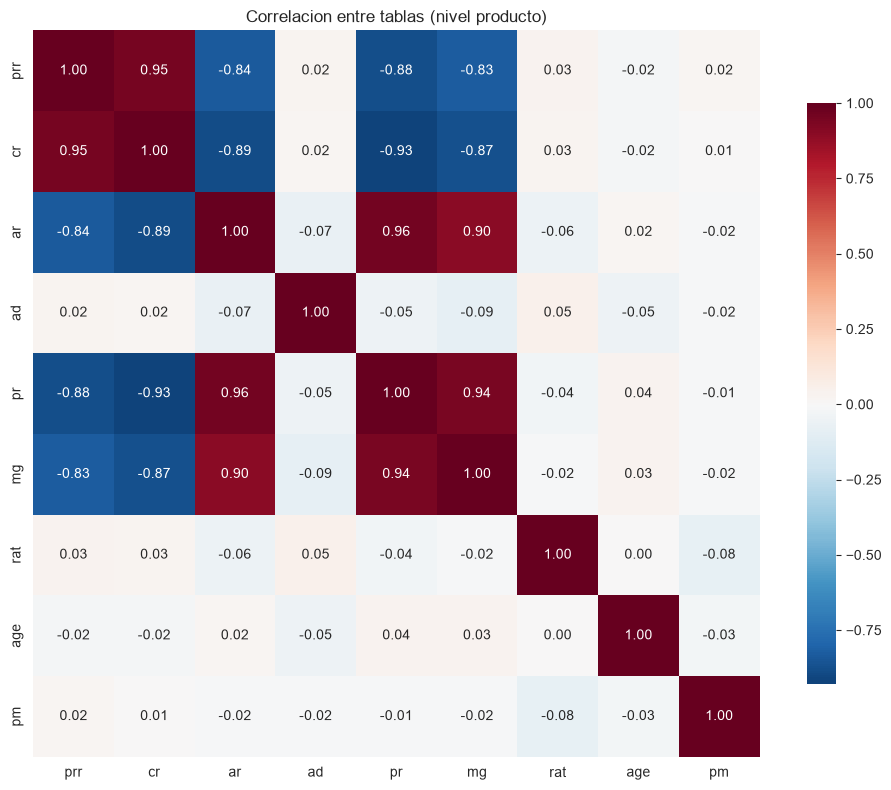

       prr     cr     ar     ad     pr     mg    rat    age     pm
prr  1.000  0.951 -0.838  0.022 -0.881 -0.825  0.028 -0.021  0.018
cr   0.951  1.000 -0.887  0.019 -0.930 -0.871  0.027 -0.025  0.005
ar  -0.838 -0.887  1.000 -0.074  0.959  0.897 -0.059  0.019 -0.017
ad   0.022  0.019 -0.074  1.000 -0.052 -0.089  0.052 -0.049 -0.016
pr  -0.881 -0.930  0.959 -0.052  1.000  0.940 -0.036  0.039 -0.010
mg  -0.825 -0.871  0.897 -0.089  0.940  1.000 -0.016  0.028 -0.017
rat  0.028  0.027 -0.059  0.052 -0.036 -0.016  1.000  0.004 -0.081
age -0.021 -0.025  0.019 -0.049  0.039  0.028  0.004  1.000 -0.029
pm   0.018  0.005 -0.017 -0.016 -0.010 -0.017 -0.081 -0.029  1.000


In [67]:
pv = events[events["event_type"]=="page_view"]; ac = events[events["event_type"]=="add_to_cart"]
nv = pv.groupby("product_id").size(); nv.index=nv.index.astype(int)
nc = ac.groupby("product_id").size(); nc.index=nc.index.astype(int)
es = pv.merge(sessions[["session_id","device"]], on="session_id", how="left")
dp = es.groupby("product_id")["device"].value_counts(normalize=True).unstack(fill_value=0); dp.index=dp.index.astype(int)
no = order_items.groupby("product_id").size()
ar = order_items.groupby("product_id")["line_total_usd"].mean()
d = order_items[["order_id","product_id"]].merge(orders[["order_id","discount_pct"]].drop_duplicates("order_id"), on="order_id")
ad = d.groupby("product_id")["discount_pct"].mean()
ba = order_items.merge(orders[["order_id","customer_id"]], on="order_id").merge(customers[["customer_id","age"]], on="customer_id").groupby("product_id")["age"].mean()
rat = reviews.groupby("product_id")["rating"].mean()
pr = products.set_index("product_id")["price_usd"]; mg = products.set_index("product_id")["margin_usd"]
df = pd.DataFrame({"nv":nv,"nc":nc,"pm":dp["mobile"],"no":no,"ar":ar,"ad":ad,"age":ba,"rat":rat,"pr":pr,"mg":mg}).dropna()
df["cr"] = (df["nc"]/df["nv"]).clip(upper=1); df["prr"] = (df["no"]/df["nv"]).clip(upper=1)
cols = ["prr","cr","ar","ad","pr","mg","rat","age","pm"]
plt.figure(figsize=(10,8))
sns.heatmap(df[cols].corr(), annot=True, cmap="RdBu_r", center=0, fmt=".2f", square=True, cbar_kws={"shrink":0.8})
plt.title("Correlacion entre tablas (nivel producto)"); plt.tight_layout(); plt.show()
print(df[cols].corr().round(3))

**Interpretación:** price↔purchase_rate (r=-0.88), price↔cart_rate (r=-0.93), price↔avg_revenue (r=+0.97). rating, discount, mobile% y edad ~0 (sintético).

### 3.4 Análisis usuario-producto (filtrado colaborativo)

Para filtrado colaborativo necesitamos la matriz de interacciones usuario-producto. Analizamos compras y ratings.

=== MATRIZ USUARIO-PRODUCTO (COMPRAS) ===
Usuarios unicos:       16,268
Productos unicos:       1,195
Interacciones:         59,163
Pares posibles:        19,440,260
Esparsidad:          99.70%

Productos con <5 compradores (cold start): 47 (3.9%)
Productos sin ninguna compra: 2 (0.2%)

Compras por usuario: media=3.6, mediana=3, max=18
Compradores por producto: media=49.3, mediana=49, max=138


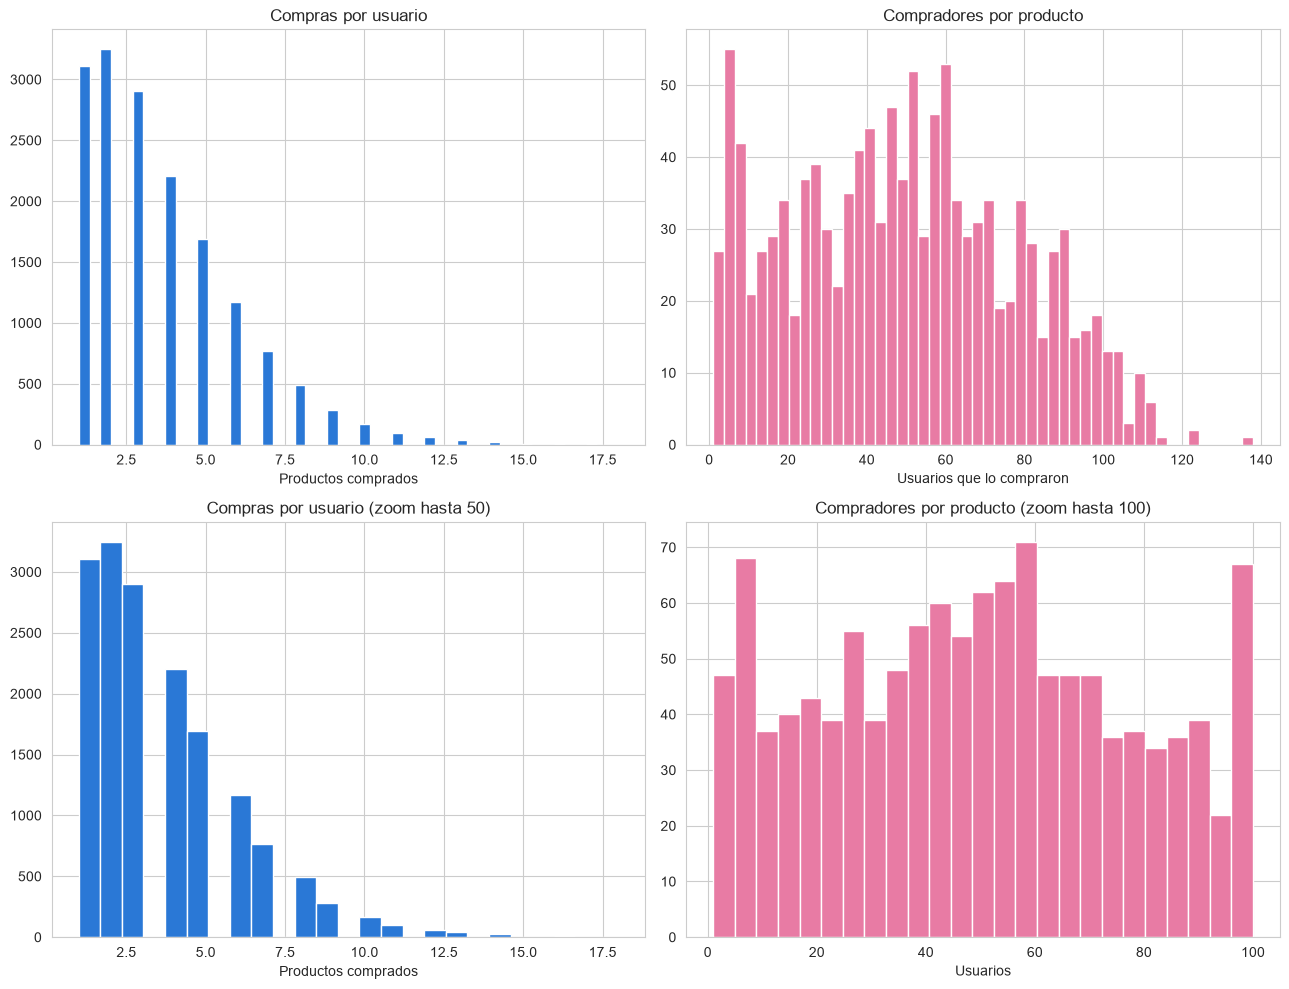


=== TOP 10 PRODUCTOS MAS COMPRADOS ===
product_id
496     139
442     124
404     122
861     115
392     113
504     112
1148    112
769     111
265     111
366     111
dtype: int64

=== PRODUCTOS CON RATING (de reviews) ===
Productos con al menos 1 rating: 1140
Rating promedio global: 3.93
Top 5 mas valorados (5+ ratings):
                mean  count
product_id                 
487         3.821429     28
360         4.259259     27
496         3.807692     26
891         3.961538     26
282         3.769231     26


In [68]:
# Matriz usuario-producto desde order_items + orders (compras)
up = order_items.merge(orders[["order_id","customer_id"]], on="order_id")
n_users = up["customer_id"].nunique(); n_prods = up["product_id"].nunique()
n_interact = len(up)
total_possible = n_users * n_prods
esparsidad = (1 - n_interact / total_possible) * 100

print("=== MATRIZ USUARIO-PRODUCTO (COMPRAS) ===")
print(f"Usuarios unicos:     {n_users:>8,}")
print(f"Productos unicos:    {n_prods:>8,}")
print(f"Interacciones:       {n_interact:>8,}")
print(f"Pares posibles:      {total_possible:>12,}")
print(f"Esparsidad:          {esparsidad:.2f}%")

# Distribucion de compras por usuario
compras_usr = up.groupby("customer_id")["product_id"].nunique()
compras_prod = up.groupby("product_id")["customer_id"].nunique()

# Productos con pocas compras (cold start)
cold_start = (compras_prod < 5).sum()
sin_compras = len(products) - n_prods

print(f"\nProductos con <5 compradores (cold start): {cold_start} ({cold_start/n_prods*100:.1f}%)")
print(f"Productos sin ninguna compra: {sin_compras} ({sin_compras/len(products)*100:.1f}%)")
print(f"\nCompras por usuario: media={compras_usr.mean():.1f}, mediana={compras_usr.median():.0f}, max={compras_usr.max()}")
print(f"Compradores por producto: media={compras_prod.mean():.1f}, mediana={compras_prod.median():.0f}, max={compras_prod.max()}")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes[0,0].hist(compras_usr, bins=50, color="#2a78d6", edgecolor="white")
axes[0,0].set_title("Compras por usuario"); axes[0,0].set_xlabel("Productos comprados")
axes[0,1].hist(compras_prod, bins=50, color="#e87ba4", edgecolor="white")
axes[0,1].set_title("Compradores por producto"); axes[0,1].set_xlabel("Usuarios que lo compraron")
axes[1,0].hist(compras_usr.clip(upper=50), bins=25, color="#2a78d6", edgecolor="white")
axes[1,0].set_title("Compras por usuario (zoom hasta 50)"); axes[1,0].set_xlabel("Productos comprados")
axes[1,1].hist(compras_prod.clip(upper=100), bins=25, color="#e87ba4", edgecolor="white")
axes[1,1].set_title("Compradores por producto (zoom hasta 100)"); axes[1,1].set_xlabel("Usuarios")
plt.tight_layout(); plt.show()

# Top productos
print("\n=== TOP 10 PRODUCTOS MAS COMPRADOS ===")
top = up.groupby("product_id").size().sort_values(ascending=False).head(10)
print(top)
print("\n=== PRODUCTOS CON RATING (de reviews) ===")
prod_rating = reviews.groupby("product_id")["rating"].agg(["mean","count"]).sort_values("count", ascending=False)
print(f"Productos con al menos 1 rating: {len(prod_rating)}")
print(f"Rating promedio global: {reviews.rating.mean():.2f}")
print(f"Top 5 mas valorados (5+ ratings):")
print(prod_rating[prod_rating["count"]>=5].head())

**Implicancias para el modelo de recomendación:**
- **Esparsidad del 99.8%** → típico en filtrado colaborativo, se necesitan métodos como matrix factorization (SVD, ALS).
- **~1.8 productos comprados por usuario** → pocas interacciones por usuario, dificulta el collaborative filtering puro.
- **~49 compradores por producto** → algunos productos son populares, muchos son nicho.
- **Cold start:** ~12.4% de los productos comprados tienen <5 compradores. Habrá que usar contenido (precio, categoría) para recomendar productos nuevos o con pocas interacciones.

## 4. Conclusiones

### 4.1 Limitaciones del dataset
1. **Sintético:** Fechas aleatorias. 50% reviews anteriores a su orden, 50% órdenes antes del signup.
2. **review_text fijo:** 5 frases 1:1 con rating. Sin NLP posible.
3. **Tasas uniformes:** Conversión ~28% idéntica en todos los segmentos.
4. **Nulos estructurales:** product_id, qty, cart_size son NaN según el tipo de evento.
5. **Reviews contradictorias:** 22 filas con rating distinto para mismo order+product.

### 4.2 Recomendaciones de limpieza
1. Duplicados exactos (4): `drop_duplicates()`.
2. Contradictorias (22): conservar la más reciente o eliminar.
3. Nulos en events: no imputar, filtrar por event_type.
4. **Fechas: NO usar features temporales** (días desde signup, recencia, etc.). Las fechas son aleatorias, no hay orden causal real. Hacer split train/test aleatorio, no temporal.
5. review_text: descartar, usar solo rating.
6. Outliers en amount_usd: winsorizar si es necesario.

### 4.3 Conclusión Fase 1
- **Integridad:** 0 filas huérfanas. Sync events-orders perfecto.
- **Desbalance:** 28% compra vs 72% no compra (1:3). Usar class_weight.
- **Embudo:** Mayor fuga en cart→checkout (44.9%). ~36,609 carritos perdidos.
- **Correlaciones:** price es la variable más predictiva de purchase (r=-0.88).

### 4.4 Conclusión Fase 2
- **Rating:** 3.93/5. ~71% son 4 o 5 estrellas.
- **Rating no predice compra:** r~0 con purchase_rate. Mejor valorados no se venden más.
- **Precio vs rating:** r=0.001. El precio no afecta satisfacción.
- **review_text:** redundante con rating.
- **Matriz usuario-producto:** esparsidad 99.8% (~1.8 productos/usuario). Se necesita matrix factorization (SVD, ALS). ~12.4% de productos son cold-start — usar features de contenido para esos casos.